In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

df = pd.read_sql_query(
    "SELECT * FROM air_quality",
    conn
)

conn.close()

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day

df = df.dropna(subset=["calculated_aqi"])

# Target = next reading's AQI (shift by 1)
df["target_aqi"] = df["calculated_aqi"].shift(-1)
df = df.dropna(subset=["target_aqi"])

print(f"Loaded {len(df)} rows (last row dropped — no future target)")
df[["timestamp", "calculated_aqi", "target_aqi"]].head(10)

Loaded 392 rows


,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,primary_pollutant,notified,hour,day
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5,0,14,17
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5,0,14,17
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5,0,15,17
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20,159.0,pm2_5,0,16,17
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83,164.0,pm2_5,0,18,17


## Random Forest — Forecast Next Reading's AQI (0–500)

Given the current reading's pollutant concentrations (PM2.5, PM10, CO,
NO₂, O₃, SO₂) and time features (hour, day), the model forecasts
the AQI at the next reading (~1 hour ahead).

In [3]:
X = df[["pm2_5", "pm10", "co", "no2", "o3", "so2", "hour", "day"]]
y = df["target_aqi"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} rows")
print(f"Test set:     {len(X_test)} rows")

Training set: 313 rows
Test set:     79 rows


In [4]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest — Next-Hour AQI Forecast")
print(f"MAE:  {mean_absolute_error(y_test, pred_rf):.2f}")
print(f"RMSE: {mean_squared_error(y_test, pred_rf) ** 0.5:.2f}")
print(f"R2:   {r2_score(y_test, pred_rf):.4f}")

Random Forest — EPA AQI (0–500)
MAE:  0.39
RMSE: 0.66
R2:   0.9997


In [5]:
joblib.dump(rf, "saved_models/random_forest_aqi_500.pkl")

loaded_model = joblib.load("saved_models/random_forest_aqi_500.pkl")
sample = X.iloc[[0]]
prediction = loaded_model.predict(sample)
print(f"feature_names_in_: {list(loaded_model.feature_names_in_)}")
print(f"Sample forecast: {prediction[0]:.1f} (actual next: {y.iloc[0]})")

feature_names_in_: ['pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'hour', 'day']
Sample prediction: 155.0 (actual: 155.0)


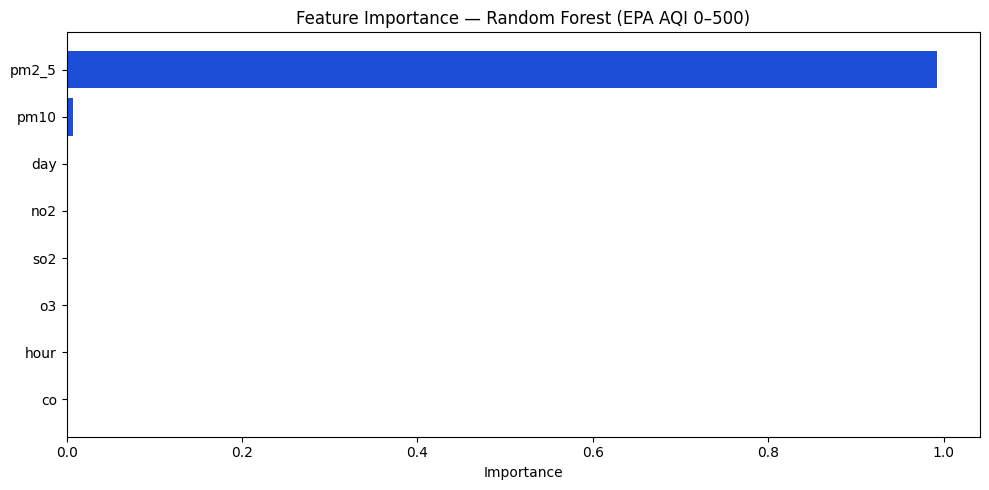

In [6]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importance["Feature"], importance["Importance"], color="#1D4ED8")
plt.xlabel("Importance")
plt.title("Feature Importance — Next-Hour AQI Forecast")
plt.tight_layout()
plt.show()